# Dense And Sparse Correspondence

----

Conda env : [cv_playgrounds](../../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://github.com/facebookresearch/dinov3/blob/main/notebooks/dense_sparse_matching.ipynb 

### Configure device

In [1]:
#@title
import torch

if torch.backends.mps.is_available():
    t_device = torch.device("mps")
    s_device = "mps"
    print(f"Current memory allocated on MPS: {torch.mps.current_allocated_memory()} bytes")
    print(f"Driver memory allocated on MPS: {torch.mps.driver_allocated_memory()} bytes")
    if torch.mps.driver_allocated_memory() - torch.mps.current_allocated_memory()< 1e4:
        print("Not enough mps memory, convert to cpu mode")
        t_device = torch.device("cpu")
        s_device = "cpu"
elif torch.cuda.is_available():
    t_device = torch.device("cuda")
    s_device = "cuda"
else:
    t_device = torch.device("cpu")
    s_device = "cpu"
print(t_device)

cuda


In [2]:
!nvidia-smi

Mon Oct  6 05:39:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 24%   43C    P8             31W /  250W |    6860MiB /  11264MiB |     35%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Setup

In [3]:
import io
import os
import pickle
import tarfile
import urllib

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.linear_model import LogisticRegression
import torch
import torchvision.transforms.functional as TF
from tqdm import tqdm


### Model Loading

In [12]:
import torch
import os

# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

# Assuming you cloned dinov3 into the same directory
DINOV3_LOCATION = "./temp_dinov3"
DINOV3_MODEL_NAME = MODEL_DINOV3_VITL
# Specify the local path to your downloaded weights
DINOV3_MODEL_PATH = "./temp/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth"

# Use `source="local"` and pass the weights path
model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model=DINOV3_MODEL_NAME,
    source="local",
    weights=DINOV3_MODEL_PATH,
)
model.to(t_device)

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-23): 24 x SelfAttentionBlock(
      (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm)

### Data

In [5]:
IMAGES_URI = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/foreground_segmentation_images.tar.gz"
LABELS_URI = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/foreground_segmentation_labels.tar.gz"

def load_images_from_remote_tar(tar_uri: str) -> list[Image.Image]:
    images = []
    with urllib.request.urlopen(tar_uri) as f:
        tar = tarfile.open(fileobj=io.BytesIO(f.read()))
        for member in tar.getmembers():
            image_data = tar.extractfile(member)
            image = Image.open(image_data)
            images.append(image)
    return images
    
images = load_images_from_remote_tar(IMAGES_URI)
labels = load_images_from_remote_tar(LABELS_URI)
n_images = len(images)
assert n_images == len(labels), f"{len(images)=}, {len(labels)=}"

print(f"Loaded {n_images} images and labels")

Loaded 9 images and labels


Showing image / mask at index 0:


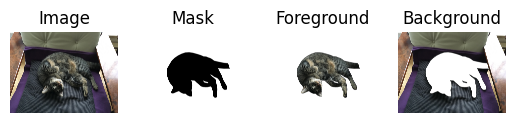

In [6]:
data_index = 0

print(f"Showing image / mask at index {data_index}:")

image = images[data_index]
mask = labels[data_index]
foreground = Image.composite(image, mask, mask)
mask_bg_np = np.copy(np.array(mask))
mask_bg_np[:, :, 3] = 255 - mask_bg_np[:, :, 3]
mask_bg = Image.fromarray(mask_bg_np)
background = Image.composite(image, mask_bg, mask_bg)

data_to_show = [image, mask, foreground, background]
data_labels = ["Image", "Mask", "Foreground", "Background"]

# plt.figure(figsize=(16, 4), dpi=300)
plt.figure()
for i in range(len(data_to_show)):
    plt.subplot(1, len(data_to_show), i + 1)
    plt.imshow(data_to_show[i])
    plt.axis('off')
    plt.title(data_labels[i], fontsize=12)
plt.show()

## Building Per-Patch Label Map

In [7]:
PATCH_SIZE = 16
IMAGE_SIZE = 768

# quantization filter for the given patch size
patch_quant_filter = torch.nn.Conv2d(1, 1, PATCH_SIZE, stride=PATCH_SIZE, bias=False)
patch_quant_filter.weight.data.fill_(1.0 / (PATCH_SIZE * PATCH_SIZE))

# image resize transform to dimensions divisible by patch size
def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))

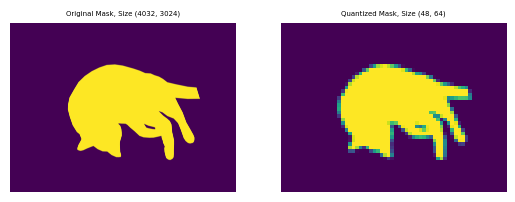

In [8]:
mask_0 = labels[0].split()[-1]
mask_0_resized = resize_transform(mask_0)
with torch.no_grad():
    mask_0_quantized = patch_quant_filter(mask_0_resized).squeeze().detach().cpu()

# plt.figure(figsize=(4, 2), dpi=300)
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(mask_0)
plt.axis('off')
plt.title(f"Original Mask, Size {mask_0.size}", fontsize=5)
plt.subplot(1, 2, 2)
plt.imshow(mask_0_quantized)
plt.axis('off')
plt.title(f"Quantized Mask, Size {tuple(mask_0_quantized.shape)}", fontsize=5)
plt.show()

### Extracting Features and Labels for All the Images

In [13]:
xs = []
ys = []
image_index = []

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

n_layers = MODEL_TO_NUM_LAYERS[DINOV3_MODEL_NAME]

with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        for i in tqdm(range(n_images), desc="Processing images"):
            # Loading the ground truth
            mask_i = labels[i].split()[-1]
            mask_i_resized = resize_transform(mask_i)
            mask_i_quantized = patch_quant_filter(mask_i_resized).squeeze().view(-1).detach().cpu()
            ys.append(mask_i_quantized)
            # Loading the image data 
            image_i = images[i].convert('RGB')
            image_i_resized = resize_transform(image_i)
            image_i_resized = TF.normalize(image_i_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            image_i_resized = image_i_resized.unsqueeze(0).cuda()

            feats = model.get_intermediate_layers(image_i_resized, n=range(n_layers), reshape=True, norm=True)
            dim = feats[-1].shape[1]
            xs.append(feats[-1].squeeze().view(dim, -1).permute(1,0).detach().cpu())

            image_index.append(i * torch.ones(ys[-1].shape))


# Concatenate all lists into torch tensors 
xs = torch.cat(xs)
ys = torch.cat(ys)
image_index = torch.cat(image_index)

# keeping only the patches that have clear positive or negative label
idx = (ys < 0.01) | (ys > 0.99)
xs = xs[idx]
ys = ys[idx]
image_index = image_index[idx]

print("Design matrix of size : ", xs.shape)
print("Label matrix of size : ", ys.shape)

Processing images:   0%|          | 0/9 [00:00<?, ?it/s]

Processing images: 100%|██████████| 9/9 [00:05<00:00,  1.79it/s]

Design matrix of size :  torch.Size([23604, 1024])
Label matrix of size :  torch.Size([23604])


## Training a Classifier and Model Selection

validation using image_01.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


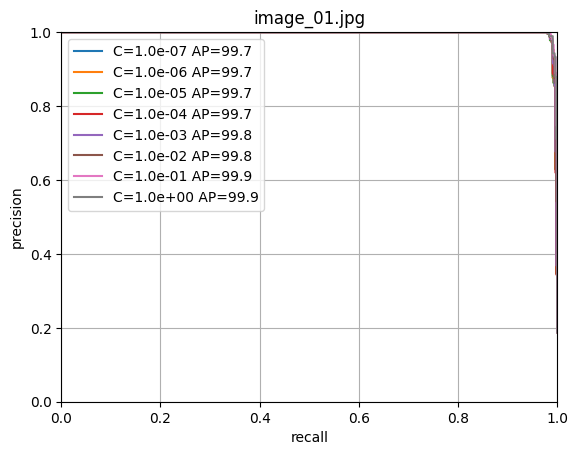

validation using image_02.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


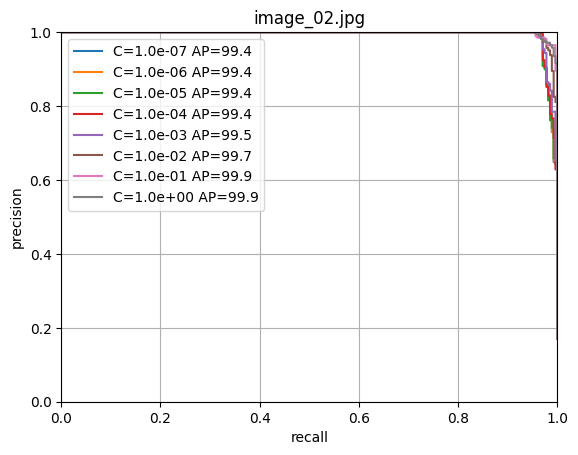

validation using image_03.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


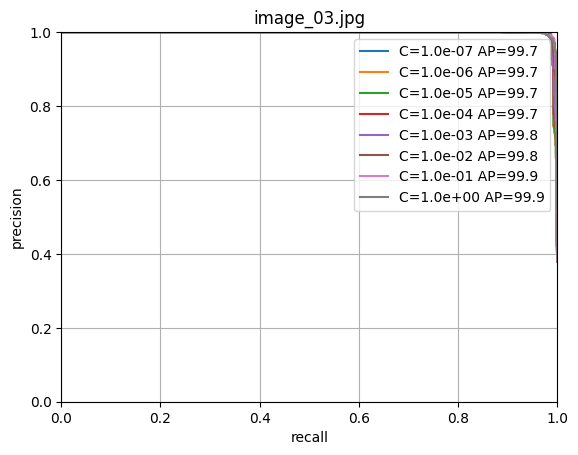

validation using image_04.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


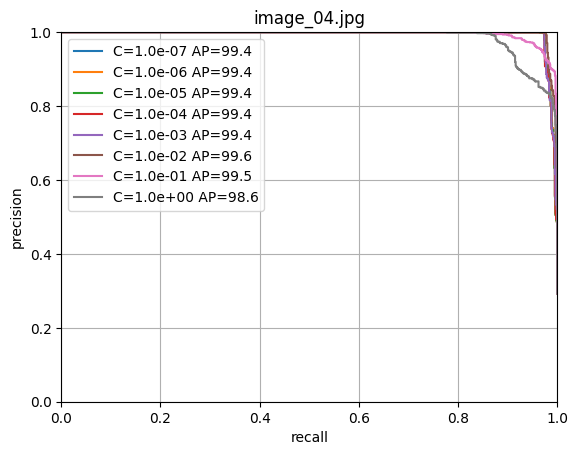

validation using image_05.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


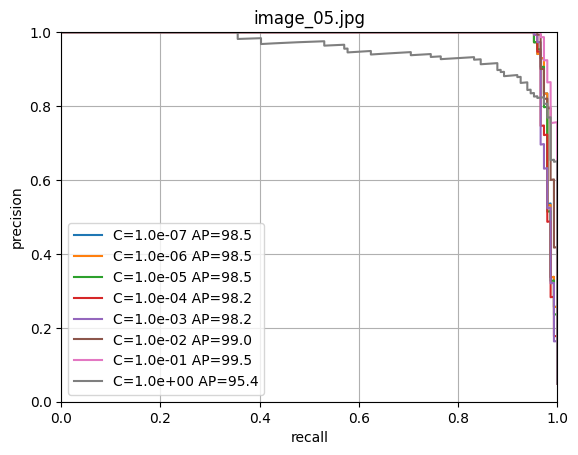

validation using image_06.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


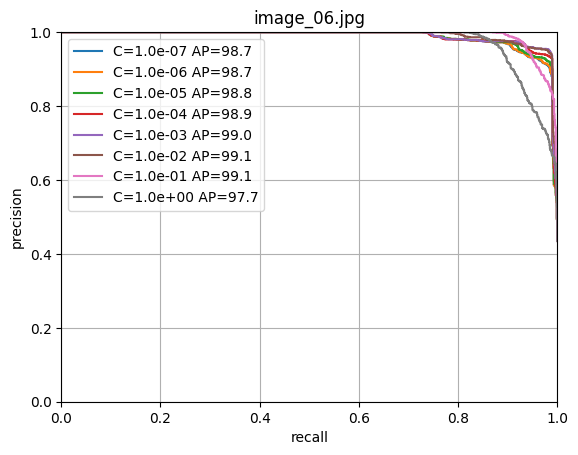

validation using image_07.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


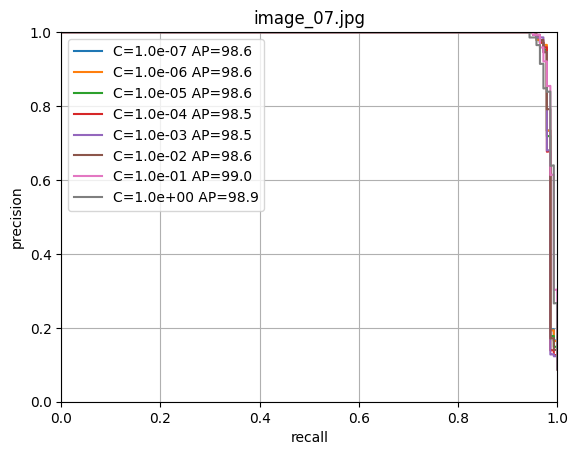

validation using image_08.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


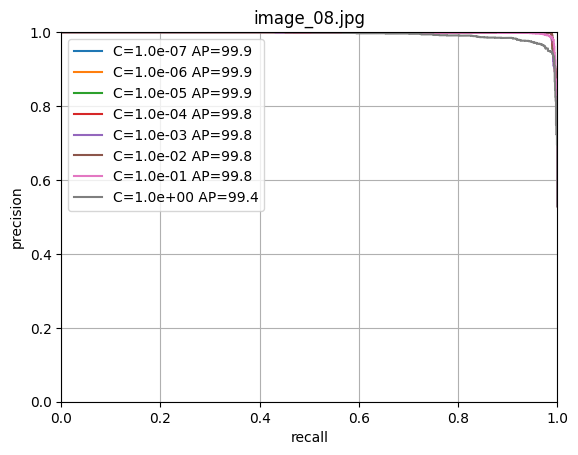

validation using image_09.jpg
training logisitic regression with C=1.00e-07
training logisitic regression with C=1.00e-06
training logisitic regression with C=1.00e-05
training logisitic regression with C=1.00e-04
training logisitic regression with C=1.00e-03
training logisitic regression with C=1.00e-02
training logisitic regression with C=1.00e-01
training logisitic regression with C=1.00e+00


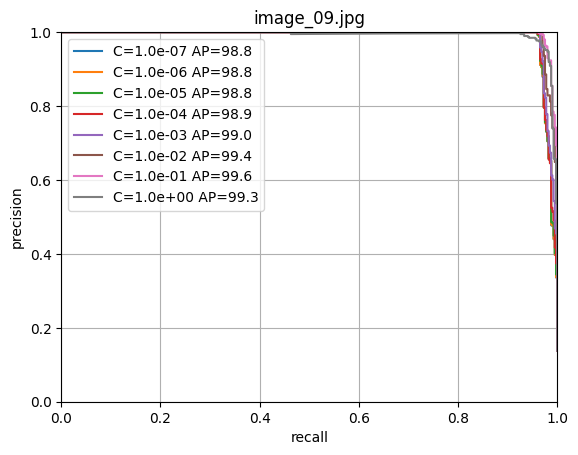

In [14]:
cs = np.logspace(-7, 0, 8)
scores = np.zeros((n_images, len(cs)))

for i in range(n_images):
    # We use leave-one-out so train will be all but image i, val will be image i
    print('validation using image_{:02d}.jpg'.format(i+1))
    train_selection = image_index != float(i)
    fold_x = xs[train_selection].numpy()
    fold_y = (ys[train_selection] > 0).long().numpy()
    val_x = xs[~train_selection].numpy()
    val_y = (ys[~train_selection] > 0).long().numpy()

    plt.figure()
    for j, c in enumerate(cs):
        print("training logisitic regression with C={:.2e}".format(c))
        clf = LogisticRegression(random_state=0, C=c, max_iter=10000).fit(fold_x, fold_y)
        output = clf.predict_proba(val_x)
        precision, recall, thresholds = precision_recall_curve(val_y, output[:, 1])
        s = average_precision_score(val_y, output[:, 1])
        scores[i, j] = s
        plt.plot(recall, precision, label='C={:.1e} AP={:.1f}'.format(c, s*100))

    plt.grid()
    plt.xlabel('recall')
    plt.title('image_{:02d}.jpg'.format(i+1))
    plt.ylabel('precision')
    plt.axis([0, 1, 0, 1])
    plt.legend()
    plt.show()

### Choosing the Best C

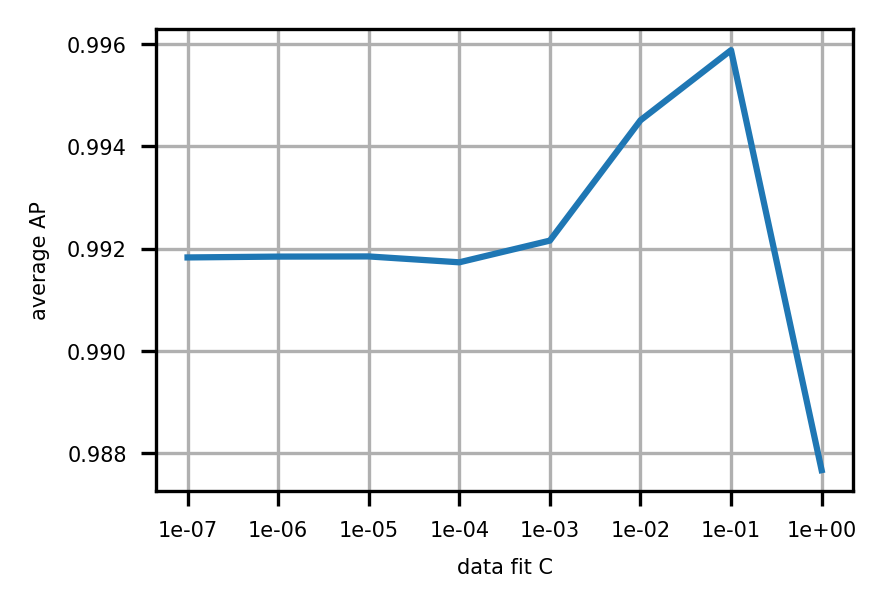

In [15]:
plt.figure(figsize=(3, 2), dpi=300)
plt.rcParams.update({
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "axes.labelsize": 5,
})
plt.plot(scores.mean(axis=0))
plt.xticks(np.arange(len(cs)), ["{:.0e}".format(c) for c in cs])
plt.xlabel('data fit C')
plt.ylabel('average AP')
plt.grid()
plt.show()

## Retraining with the optimal regularization

In [16]:
clf = LogisticRegression(random_state=0, C=0.1, max_iter=100000, verbose=2).fit(xs.numpy(), (ys > 0).long().numpy())

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished


## Test Images and Inference

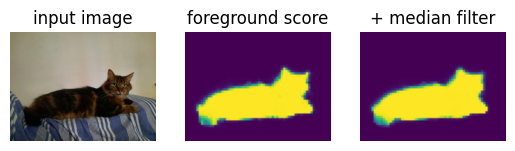

In [17]:
test_image_fpath = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/test_image.jpg"

def load_image_from_url(url: str) -> Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")


test_image = load_image_from_url(test_image_fpath)
test_image_resized = resize_transform(test_image)
test_image_normalized = TF.normalize(test_image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)

with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        feats = model.get_intermediate_layers(test_image_normalized.unsqueeze(0).cuda(), n=range(n_layers), reshape=True, norm=True)
        x = feats[-1].squeeze().detach().cpu()
        dim = x.shape[0]
        x = x.view(dim, -1).permute(1, 0)

h_patches, w_patches = [int(d / PATCH_SIZE) for d in test_image_resized.shape[1:]]

fg_score = clf.predict_proba(x)[:, 1].reshape(h_patches, w_patches)
fg_score_mf = torch.from_numpy(signal.medfilt2d(fg_score, kernel_size=3))

# plt.figure(figsize=(9, 3), dpi=300)
plt.figure()
plt.subplot(1, 3, 1)
plt.axis('off')
plt.imshow(test_image_resized.permute(1, 2, 0))
plt.title('input image')
plt.subplot(1, 3, 2)
plt.axis('off')
plt.imshow(fg_score)
plt.title('foreground score')
plt.subplot(1, 3, 3)
plt.axis('off')
plt.imshow(fg_score_mf)
plt.title('+ median filter')
plt.show()

### Saving the Model for Future Use

In [19]:

save_root = './temp_dinov3_model'
model_path = os.path.join(save_root, "fg_classifier.pkl")
with open(model_path, "wb") as f:
  pickle.dump(clf, f)